# Exercise 6 — Conjugate Gradient Method

This notebook solves **Exercise Sheet 6: Conjugate Gradient Method** in a simple Python style.

We keep the code readable and beginner-friendly.

## What we solve

We minimize the quadratic function

\[
f(x) = \frac{1}{2}x^TQx + p^Tx + c
\]

For this function, the gradient is

\[
\nabla f(x) = Qx + p
\]

At the minimum:

\[
\nabla f(x) = 0
\]

So the exact solution satisfies

\[
Qx = -p
\]

The exercise asks us to implement the **Conjugate Gradient Method** and test it for the tridiagonal matrix \(T_n\).

## 1. Import libraries

We use:

- `numpy` for vectors and matrices
- `matplotlib` for plots
- `scipy.sparse.diags` to create large tridiagonal matrices easily

Sparse matrices are useful here because the matrix for \(n = 1000\) is large, but most entries are zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

np.random.seed(0)

## 2. Create the tridiagonal matrix \(T_n\)

The matrix from the exercise is

\[
T_n =
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & -1 \\
0 & 0 & 0 & -1 & 2
\end{bmatrix}
\]

The diagonal contains `2`.

The upper and lower diagonals contain `-1`.

In [2]:
def create_tridiagonal_matrix(n):
    """
    Create the tridiagonal matrix T_n.

    Main diagonal: 2
    Upper diagonal: -1
    Lower diagonal: -1

    We return a sparse matrix so that large n is still easy to handle.
    """
    main_diagonal = 2 * np.ones(n)
    upper_diagonal = -1 * np.ones(n - 1)
    lower_diagonal = -1 * np.ones(n - 1)

    Q = diags(
        diagonals=[lower_diagonal, main_diagonal, upper_diagonal],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return Q

Let us test this for a small matrix.

In [3]:
Q_small = create_tridiagonal_matrix(5)

print(Q_small.toarray())

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


## 3. Define the quadratic function and its gradient

The exercise uses

\[
f(x) = \frac{1}{2}x^TQx + p^Tx + c
\]

For the tasks:

\[
p = [1,1,\dots,1]^T
\]

and

\[
c = 0
\]

The gradient is

\[
\nabla f(x) = Qx + p
\]

In [4]:
def quadratic_function(Q, p, x, c=0):
    """
    Compute f(x) = 1/2 x^T Q x + p^T x + c
    """
    return 0.5 * x @ (Q @ x) + p @ x + c


def gradient(Q, p, x):
    """
    Gradient of f(x).

    grad f(x) = Qx + p
    """
    return Q @ x + p

## 4. Implement the Conjugate Gradient Method

The algorithm uses four main vectors:

- `x` — current solution
- `g` — current gradient
- `d` — search direction
- `z` — matrix-vector product \(Qd\)

The PDF says that we need four fields in memory: `x`, `d`, `z`, and `g`.

So the memory requirement is proportional to \(4n\), which is still

\[
O(n)
\]

because constants are ignored in Big-O notation.

In [5]:
def conjugate_gradient(Q, p, x0, tol=1e-5, maxit=2000):
    """
    Conjugate Gradient method for minimizing:

        f(x) = 1/2 x^T Q x + p^T x + c

    The gradient is:

        g = Qx + p

    Parameters
    ----------
    Q : matrix
        Symmetric positive definite matrix.
    p : vector
        Linear part of the quadratic function.
    x0 : vector
        Starting point.
    tol : float
        Stop when the gradient norm is smaller than this.
    maxit : int
        Maximum number of iterations.

    Returns
    -------
    x : vector
        Final solution.
    residuals : list
        Norm of the gradient at every iteration.
    """

    x = x0.copy()

    # g_0 = grad f(x_0)
    g = gradient(Q, p, x)

    # d_0 = -g_0
    d = -g

    # residual = ||g||
    res = np.linalg.norm(g)

    residuals = [res]

    k = 0

    while res > tol and k < maxit:
        # z_k = Q d_k
        z = Q @ d

        # alpha_k = res^2 / (d^T z)
        alpha = (res ** 2) / (d @ z)

        # x_{k+1}
        x = x + alpha * d

        # g_{k+1}
        g = g + alpha * z

        # new residual
        res_new = np.linalg.norm(g)
        residuals.append(res_new)

        # beta_k = res_new^2 / res_old^2
        beta = (res_new ** 2) / (res ** 2)

        # d_{k+1}
        d = -g + beta * d

        # update residual
        res = res_new

        k = k + 1

    return x, residuals

## 5. Test CG for different dimensions

The exercise asks us to test

\[
n = 5,\ 50,\ 100,\ 500,\ 1000
\]

We choose a random starting vector:

\[
x^0 = \text{np.random.random}(n)
\]

For each dimension we print:

- number of iterations
- final residual
- error compared to the exact solution from `np.linalg.solve`

For large \(n\), we convert \(Q\) to a dense matrix only when calculating the exact solution.  
This is acceptable for this exercise, but in real large problems we avoid dense matrices.

In [6]:
dimensions = [5, 50, 100, 500, 1000]

cg_results = {}

for n in dimensions:
    Q = create_tridiagonal_matrix(n)
    p = np.ones(n)
    x0 = np.random.random(n)

    x_cg, residuals = conjugate_gradient(Q, p, x0, tol=1e-5, maxit=3000)

    # Exact solution: Qx = -p
    # For checking only, use dense matrix.
    x_exact = spsolve(Q, -p)

    error = np.linalg.norm(x_cg - x_exact)

    cg_results[n] = residuals

    print("n =", n)
    print("iterations:", len(residuals) - 1)
    print("final residual:", residuals[-1])
    print("error compared to exact solution:", error)
    print("-" * 50)

n = 5
iterations: 5
final residual: 2.227836817101989e-16
error compared to exact solution: 2.945754565036118e-15
--------------------------------------------------
n = 50
iterations: 50
final residual: 6.172490475733197e-14
error compared to exact solution: 1.239811408805643e-11
--------------------------------------------------
n = 100
iterations: 100
final residual: 9.354597589924379e-14
error compared to exact solution: 5.587405832189726e-11
--------------------------------------------------
n = 500
iterations: 500
final residual: 1.6856267806937902e-13
error compared to exact solution: 3.6036439246238655e-08
--------------------------------------------------


n = 1000
iterations: 1000
final residual: 2.0658564479091255e-12
error compared to exact solution: 7.253062892312458e-07
--------------------------------------------------


## 6. Plot the residuals

The residual is

\[
\|\nabla f(x_k)\|
\]

A smaller residual means we are closer to the minimum.

We plot the residual on a logarithmic scale.

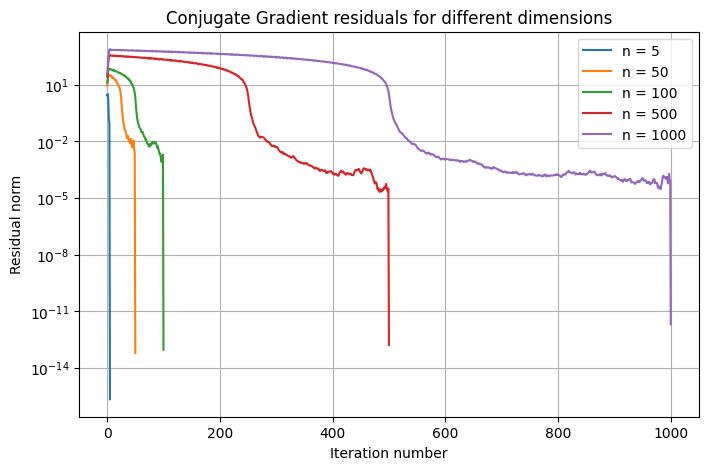

In [7]:
plt.figure(figsize=(8, 5))

for n, residuals in cg_results.items():
    plt.semilogy(residuals, label=f"n = {n}")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Conjugate Gradient residuals for different dimensions")
plt.legend()
plt.grid(True)
plt.show()

## 7. Observation for different dimensions

For a quadratic problem with a symmetric positive definite matrix, the CG method can theoretically solve the problem in at most \(n\) iterations.

So for larger \(n\), more iterations may be needed.

But the method is still usually much faster than simple gradient descent because CG uses better search directions.

# Task 2(b): Effect of a high condition number

The condition number is

\[
K = \frac{\lambda_{\max}}{\lambda_{\min}}
\]

If \(K\) is large, the problem is ill-conditioned.

That means the function has a long narrow valley.

Optimization methods usually become slower for ill-conditioned problems.

## 8. Create matrices with different condition numbers

Here we create matrices with the same eigenvectors but different eigenvalues.

This lets us control the condition number.

In [8]:
def create_matrix_with_condition_number(n, condition_number):
    """
    Create a symmetric positive definite matrix with a chosen condition number.

    We use eigenvectors from the tridiagonal matrix,
    but replace the eigenvalues by values between 1 and condition_number.
    """

    Q_base = create_tridiagonal_matrix(n).toarray()

    # Eigenvalue decomposition
    eigenvalues, V = np.linalg.eigh(Q_base)

    # New eigenvalues from 1 to condition_number
    new_eigenvalues = np.linspace(1, condition_number, n)

    # Build new matrix
    Q_new = V @ np.diag(new_eigenvalues) @ V.T

    return Q_new

In [9]:
n = 50
condition_numbers = [10, 100, 1000, 10000]

ill_conditioned_results = {}

for K in condition_numbers:
    Q = create_matrix_with_condition_number(n, K)
    p = np.ones(n)
    x0 = np.random.random(n)

    x_cg, residuals = conjugate_gradient(Q, p, x0, tol=1e-5, maxit=3000)

    ill_conditioned_results[K] = residuals

    print("Condition number K =", K)
    print("iterations:", len(residuals) - 1)
    print("final residual:", residuals[-1])
    print("-" * 50)

Condition number K = 10
iterations: 19
final residual: 6.94881477770484e-06
--------------------------------------------------
Condition number K = 100
iterations: 35
final residual: 7.768096483508189e-06
--------------------------------------------------
Condition number K = 1000
iterations: 43
final residual: 4.445522083870527e-06
--------------------------------------------------
Condition number K = 10000
iterations: 46
final residual: 2.317243345305039e-06
--------------------------------------------------


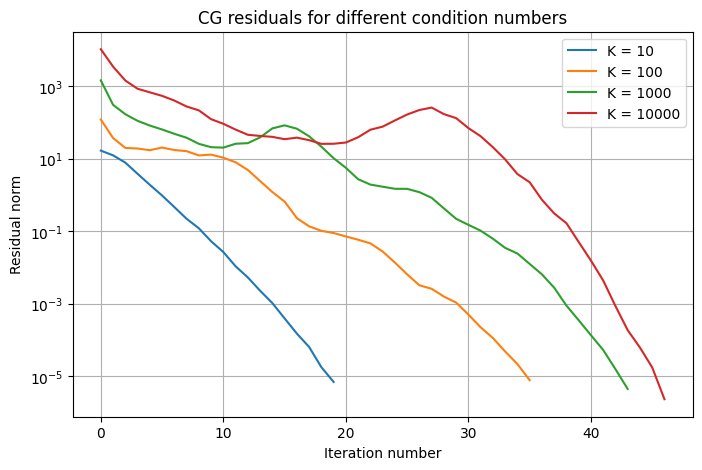

In [10]:
plt.figure(figsize=(8, 5))

for K, residuals in ill_conditioned_results.items():
    plt.semilogy(residuals, label=f"K = {K}")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("CG residuals for different condition numbers")
plt.legend()
plt.grid(True)
plt.show()

## 9. Observation about condition number

When the condition number becomes larger, convergence becomes slower.

This is because the quadratic function becomes more stretched.

A simple picture:

- low condition number: round bowl, easy to move to the minimum
- high condition number: long narrow valley, harder to move efficiently

CG still performs well compared to many gradient methods, but high condition number can still make it slower.

# Task 2(c): Compare CG with other methods

For \(n = 100\), compare:

1. Conjugate Gradient Method
2. Heavy-Ball Method
3. Malitsky-Mishchenko Method
4. Gradient Method with full relaxation

We use the same quadratic problem:

\[
Q = T_n,\quad p = \mathbf{1}
\]

and the same random starting vector.

## 10. Helper: compute eigenvalue bounds

For heavy-ball we need:

\[
\mu = \lambda_{\min}(Q)
\]

and

\[
L = \lambda_{\max}(Q)
\]

In [11]:
def get_mu_and_L(Q):
    """
    Compute smallest and largest eigenvalues.

    We use dense eigenvalue computation here only because n=100 is small.
    """
    if hasattr(Q, "toarray"):
        Q_dense = Q.toarray()
    else:
        Q_dense = Q

    eigenvalues = np.linalg.eigvalsh(Q_dense)

    mu = eigenvalues[0]
    L = eigenvalues[-1]

    return mu, L

## 11. Gradient method with full relaxation

For quadratic functions:

\[
\alpha_k =
\frac{\|\nabla f(x_k)\|^2}
{\nabla f(x_k)^T Q \nabla f(x_k)}
\]

This chooses a good step size for the current gradient direction.

In [12]:
def gradient_full_relaxation(Q, p, x0, tol=1e-5, maxit=2000):
    """
    Gradient descent with full relaxation step size.
    """

    x = x0.copy()
    residuals = []
    step_sizes = []

    for k in range(maxit):
        g = gradient(Q, p, x)
        res = np.linalg.norm(g)

        residuals.append(res)

        if res < tol:
            break

        Qg = Q @ g

        alpha = (g @ g) / (g @ Qg)

        x = x - alpha * g

        step_sizes.append(alpha)

    return x, residuals, step_sizes

## 12. Heavy-Ball Method

The heavy-ball method adds momentum:

\[
x_{k+1} = x_k - \alpha \nabla f(x_k) + \beta(x_k - x_{k-1})
\]

The extra term

\[
\beta(x_k - x_{k-1})
\]

acts like inertia.

It remembers the previous direction and can move faster through long valleys.

In [13]:
def heavy_ball(Q, p, x0, mu, L, tol=1e-5, maxit=2000):
    """
    Heavy-ball method for strongly convex quadratic problems.
    """

    x_old = x0.copy()

    alpha = 4 / (np.sqrt(L) + np.sqrt(mu))**2
    beta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu)))**2

    x = x_old - alpha * gradient(Q, p, x_old)

    residuals = [np.linalg.norm(gradient(Q, p, x_old))]
    step_sizes = [alpha]

    for k in range(maxit):
        g = gradient(Q, p, x)
        res = np.linalg.norm(g)

        residuals.append(res)

        if res < tol:
            break

        x_new = x - alpha * g + beta * (x - x_old)

        x_old = x
        x = x_new

        step_sizes.append(alpha)

    return x, residuals, step_sizes

## 13. Malitsky-Mishchenko Method

This method automatically estimates a useful step size.

So we do not need to know \(L\) in advance.

The step size changes during the iterations.

In [14]:
def malitsky_mishchenko(Q, p, x0, tol=1e-5, maxit=2000):
    """
    Malitsky-Mishchenko step size control.

    This is written in a simple way so that the formula is easy to follow.
    """

    alpha_old = 1e-16
    theta_old = 1e16

    x_old = x0.copy()
    x = x_old - alpha_old * gradient(Q, p, x_old)

    residuals = [np.linalg.norm(gradient(Q, p, x))]
    step_sizes = [alpha_old]

    for k in range(1, maxit):
        g = gradient(Q, p, x)
        g_old = gradient(Q, p, x_old)

        difference_x = np.linalg.norm(x - x_old)
        difference_g = np.linalg.norm(g - g_old)

        first_choice = np.sqrt(1 + theta_old) * alpha_old

        if difference_g == 0:
            second_choice = first_choice
        else:
            second_choice = difference_x / (2 * difference_g)

        alpha = min(first_choice, second_choice)

        theta = alpha / alpha_old

        x_new = x - alpha * g

        res = np.linalg.norm(gradient(Q, p, x_new))
        residuals.append(res)
        step_sizes.append(alpha)

        if res < tol:
            break

        x_old = x
        x = x_new
        alpha_old = alpha
        theta_old = theta

    return x, residuals, step_sizes

## 14. Run the comparison for \(n = 100\)

In [15]:
n = 100

Q = create_tridiagonal_matrix(n)
p = np.ones(n)
x0 = np.random.random(n)

mu, L = get_mu_and_L(Q)

print("mu =", mu)
print("L =", L)
print("condition number =", L / mu)

mu = 0.0009674354160243079
L = 3.9990325645839753
condition number = 4133.642926799255


In [16]:
x_cg, res_cg = conjugate_gradient(Q, p, x0, tol=1e-5, maxit=2000)
x_hb, res_hb, alpha_hb = heavy_ball(Q, p, x0, mu, L, tol=1e-5, maxit=2000)
x_mm, res_mm, alpha_mm = malitsky_mishchenko(Q, p, x0, tol=1e-5, maxit=2000)
x_fr, res_fr, alpha_fr = gradient_full_relaxation(Q, p, x0, tol=1e-5, maxit=2000)

print("CG iterations:", len(res_cg) - 1)
print("Heavy-ball iterations:", len(res_hb) - 1)
print("Malitsky-Mishchenko iterations:", len(res_mm) - 1)
print("Full relaxation iterations:", len(res_fr) - 1)

CG iterations: 100
Heavy-ball iterations: 586
Malitsky-Mishchenko iterations: 1999
Full relaxation iterations: 1999


## 15. Plot residual comparison

The method with the fastest decreasing residual converges faster.

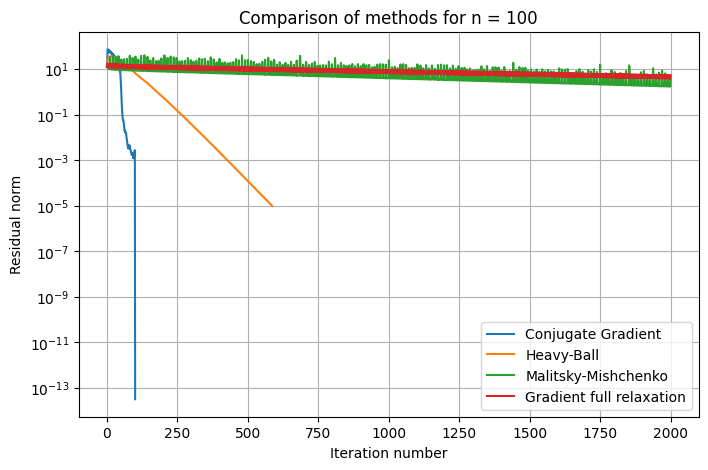

In [17]:
plt.figure(figsize=(8, 5))

plt.semilogy(res_cg, label="Conjugate Gradient")
plt.semilogy(res_hb, label="Heavy-Ball")
plt.semilogy(res_mm, label="Malitsky-Mishchenko")
plt.semilogy(res_fr, label="Gradient full relaxation")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Comparison of methods for n = 100")
plt.legend()
plt.grid(True)
plt.show()

## 16. Plot step sizes

CG computes its step size internally together with the search direction.

So here we plot step sizes for:

- Heavy-ball
- Malitsky-Mishchenko
- Full relaxation

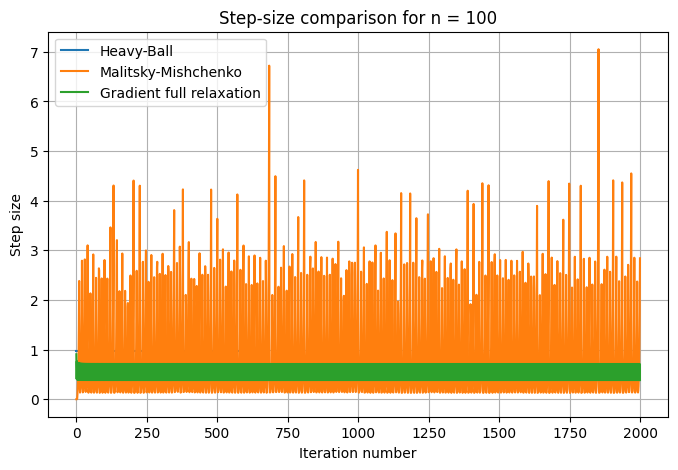

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(alpha_hb, label="Heavy-Ball")
plt.plot(alpha_mm, label="Malitsky-Mishchenko")
plt.plot(alpha_fr, label="Gradient full relaxation")

plt.xlabel("Iteration number")
plt.ylabel("Step size")
plt.title("Step-size comparison for n = 100")
plt.legend()
plt.grid(True)
plt.show()

# 17. Memory requirement comparison

## Conjugate Gradient

The exercise says that CG needs four different fields:

\[
x,\ d,\ z,\ g
\]

Each vector has length \(n\).

So the memory is approximately:

\[
4n
\]

Therefore:

\[
O(n)
\]

## Heavy-Ball Method

Heavy-ball needs at least:

- current point \(x_k\)
- previous point \(x_{k-1}\)
- gradient

So it also needs memory proportional to \(n\):

\[
O(n)
\]

## Malitsky-Mishchenko Method

Malitsky-Mishchenko needs:

- current point
- previous point
- current gradient
- previous gradient or gradient difference

So it is also:

\[
O(n)
\]

## Gradient method with full relaxation

This method needs:

- current point
- gradient
- matrix-vector product

So it is also:

\[
O(n)
\]

## Important conclusion

All methods have memory order:

\[
O(n)
\]

But CG has a larger constant factor because it explicitly stores four vectors.

# 18. Final observations

## Which method is preferred?

### Conjugate Gradient

Best choice for symmetric positive definite quadratic problems.

For example:

\[
f(x)=\frac{1}{2}x^TQx+p^Tx+c
\]

CG is very strong here because it uses conjugate directions.

### Heavy-Ball

Useful when \(\mu\) and \(L\) are known.

It can be fast, but if the parameters are not good, it can oscillate.

### Malitsky-Mishchenko

Useful when we do not know the Lipschitz constant \(L\).

It automatically adapts the step size.

### Gradient method with full relaxation

Simple and easy to understand.

Good for learning, but usually slower than CG for quadratic problems.

## My practical choice

For this exercise and this quadratic problem, I would prefer:

\[
\boxed{\text{Conjugate Gradient Method}}
\]

because the problem is exactly the type of problem CG is designed for.

# 19. Small beginner summary

The function is a bowl-shaped quadratic function.

The minimum is where:

\[
Qx+p=0
\]

The gradient method follows the steepest downhill direction.

The conjugate gradient method is smarter.

It chooses directions that do not destroy the progress made before.

That is why CG is usually much faster for quadratic problems.